In [48]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
import scipy.optimize as sco

# Input parameters
# Nacelle
Mass_RNA = 350000             # [kg]

# tower
H_Tower = 80                    # [m]
m_Tower = 347500/H_Tower                   # [kg/m]
D_avg=(6.5 + 3.87) / 2        # [m]
t_avg = (0.027 + 0.019) / 2       # [m]
A = np.pi * D_avg * t_avg          # [m2]
I = np.pi * D_avg**3 * t_avg / 8  # [m4]
E = 210e9                       # [N/m2]
EI_Tower = E * I                 # [N.m2]
EA_Tower = E * A                 # [N]


#spar 
M_spar = 7466330                # [kg]
I_spar = 4229230000                 # [kg.m2]

#wave parameters
H_Wave = 6.0 #[m]
T_wave = 10.0 #[s]
T_total = 200.0  #[s]

#time vector
dt= 0.05
T = np.arange(0, T_total, dt)
nT = len(T)


Equilibrium horizontal tension H = 783998.27 N
Equilibrium vertical tension V0 = -556675.06 N
Equilibrium horizontal span = 848.67 m
Equilibrium vertical drop = -250.00 m
Tangent stiffness matrix K = dF/dU [N/m]:
[[19629.40185754 -5255.37000889]
 [-5255.38173759  2443.56781847]]
Jacobian J = dU/dF [m/N]:
[[0.0001201  0.00025829]
 [0.00025829 0.00096474]]


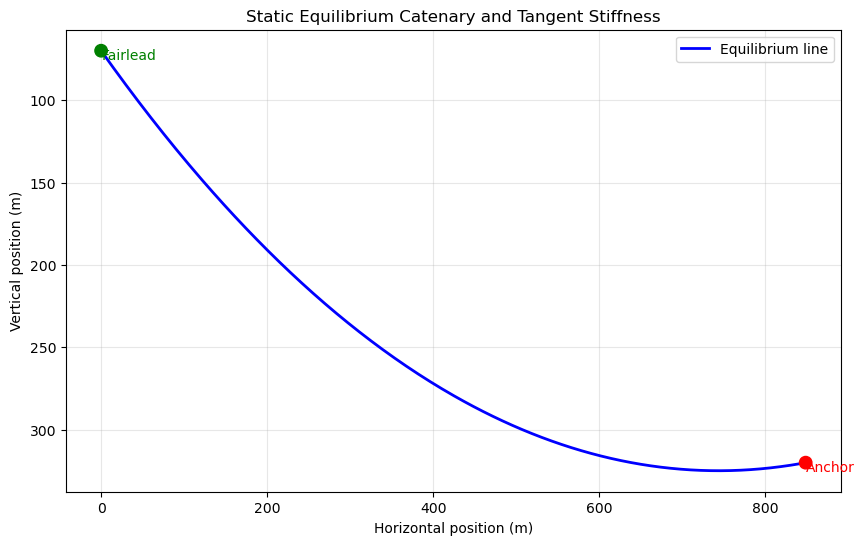

In [49]:
# Catenary parameters

r_anchor_centerline = 853.87  # m
r_fairlead_centerline = 5.2    # m
x_anchor = r_anchor_centerline - r_fairlead_centerline
Unstretched_L = 902.2  # m
D_moor = 0.09  # m

Mooring_line_density = 77.7066  # kg/m
W_moor = 698.094  # N/m
EA_moor = 384243000  # N
z_fairlead = -70  # fairlead depth below SWL (250 m above seabed)
z_anchor = -320  # anchor depth below SWL
dz_total = z_anchor - z_fairlead  # vertical drop from fairlead to anchor = 250 m


def segment_displacements(H, V_end, L_seg, w, EA):
    """Return dx and dz for a line segment using the elastic catenary equations."""
    W_seg = w * L_seg
    V_start = V_end - W_seg
    dx = H * L_seg / EA + H * L_seg / W_seg * (
        np.arcsinh(V_end / H) - np.arcsinh(V_start / H)
    )
    dz = W_seg * L_seg / EA * (V_end / W_seg - 0.5) + H * L_seg / W_seg * (
        np.sqrt(1.0 + (V_end / H) ** 2) - np.sqrt(1.0 + (V_start / H) ** 2)
    )
    return dx, dz


def elastic_catenary_shape(H, V0, total_length, w, EA, n_segments=300):
    """Compute elastic catenary coordinates from fairlead to anchor."""
    dL = total_length / n_segments
    x = 0.0
    z = 0.0
    V = V0
    x_coords = [0.0]
    z_coords = [0.0]

    for _ in range(n_segments):
        V_end = V + w * dL
        dx, dz = segment_displacements(H, V_end, dL, w, EA)
        x += dx
        z += dz
        x_coords.append(x)
        z_coords.append(z)
        V = V_end

    return np.array(x_coords), np.array(z_coords), x, z


def equilibrium_geometry(x_target, z_target, total_length, w, EA, initial_guess=(1e6, 1e5)):
    """Solve the full elastic catenary for static equilibrium geometry."""
    def residual(vars):
        H, V0 = vars
        _, _, x_end, z_end = elastic_catenary_shape(H, V0, total_length, w, EA)
        return [x_end - x_target, z_end - z_target]

    solution = sco.root(residual, initial_guess, method='hybr')
    if not solution.success:
        raise RuntimeError('Equilibrium solve failed: ' + solution.message)
    return solution.x


def tangent_stiffness(H_eq, V0_eq, total_length, w, EA, eps_H=1e3, eps_V0=1e3):
    """Compute the tangent stiffness matrix about the equilibrium state."""
    x_plus_H = elastic_catenary_shape(H_eq + eps_H, V0_eq, total_length, w, EA)[2]
    x_minus_H = elastic_catenary_shape(H_eq - eps_H, V0_eq, total_length, w, EA)[2]
    z_plus_H = elastic_catenary_shape(H_eq + eps_H, V0_eq, total_length, w, EA)[3]
    z_minus_H = elastic_catenary_shape(H_eq - eps_H, V0_eq, total_length, w, EA)[3]

    x_plus_V0 = elastic_catenary_shape(H_eq, V0_eq + eps_V0, total_length, w, EA)[2]
    x_minus_V0 = elastic_catenary_shape(H_eq, V0_eq - eps_V0, total_length, w, EA)[2]
    z_plus_V0 = elastic_catenary_shape(H_eq, V0_eq + eps_V0, total_length, w, EA)[3]
    z_minus_V0 = elastic_catenary_shape(H_eq, V0_eq - eps_V0, total_length, w, EA)[3]

    dx_dH = (x_plus_H - x_minus_H) / (2.0 * eps_H)
    dz_dH = (z_plus_H - z_minus_H) / (2.0 * eps_H)
    dx_dV0 = (x_plus_V0 - x_minus_V0) / (2.0 * eps_V0)
    dz_dV0 = (z_plus_V0 - z_minus_V0) / (2.0 * eps_V0)

    J = np.array([[dx_dH, dx_dV0], [dz_dH, dz_dV0]])
    K = np.linalg.inv(J)
    return J, K


H_eq, V0_eq = equilibrium_geometry(x_anchor, dz_total, Unstretched_L, W_moor, EA_moor)
J_eq, K_eq = tangent_stiffness(H_eq, V0_eq, Unstretched_L, W_moor, EA_moor)

x_line, z_line, _, _ = elastic_catenary_shape(H_eq, V0_eq, Unstretched_L, W_moor, EA_moor)
z_line_abs = -z_fairlead - z_line

print(f'Equilibrium horizontal tension H = {H_eq:.2f} N')
print(f'Equilibrium vertical tension V0 = {V0_eq:.2f} N')
print(f'Equilibrium horizontal span = {x_line[-1]:.2f} m')
print(f'Equilibrium vertical drop = {z_line[-1]:.2f} m')
print('Tangent stiffness matrix K = dF/dU [N/m]:')
print(K_eq)
print('Jacobian J = dU/dF [m/N]:')
print(J_eq)

# Plot equilibrium catenary
plt.figure(figsize=(10, 6))
plt.plot(x_line, z_line_abs, '-b', linewidth=2, label='Equilibrium line')
plt.scatter([0.0, x_anchor], [-z_fairlead, -z_anchor], c=['green', 'red'], s=80, zorder=5)
plt.text(0.0, -z_fairlead + 5, 'Fairlead', color='green')
plt.text(x_anchor, -z_anchor + 5, 'Anchor', color='red')
plt.title('Static Equilibrium Catenary and Tangent Stiffness')
plt.xlabel('Horizontal position (m)')
plt.ylabel('Vertical position (m)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.show()
